# 市場モデリング分析：負の二項分布によるブランド別購買行動の理解

Dunnhumby "The Complete Journey" の SOFT DRINKS カテゴリを対象に、負の二項分布（NBD）モデルで各ブランドの購買行動をモデリングする。ブランド間のパラメータ比較を通じて、平均購入回数だけでは見えない「浸透率」と「購入頻度」の違いを明らかにする。

## Step 1: データ取得・前処理

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Hiragino Sans"

### 1.1 Kaggle API でデータ取得

In [2]:
DATA_DIR = "../data/dunnhumby"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    os.system("kaggle datasets download frtgnn/dunnhumby-the-complete-journey -p ../data/dunnhumby --unzip")

### 1.2 データ読み込み

In [3]:
df_trans = pd.read_csv(os.path.join(DATA_DIR, "transaction_data.csv"))
df_product = pd.read_csv(os.path.join(DATA_DIR, "product.csv"))

In [4]:
df_trans.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [5]:
df_product.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


### 1.3 SOFT DRINKS のフィルタリング

In [6]:
soft_drink_ids = df_product.loc[
    df_product["COMMODITY_DESC"] == "SOFT DRINKS", "PRODUCT_ID"
].unique()

df_sd = df_trans[df_trans["PRODUCT_ID"].isin(soft_drink_ids)].copy()
df_sd = df_sd.merge(
    df_product[["PRODUCT_ID", "BRAND", "MANUFACTURER"]],
    on="PRODUCT_ID",
    how="left",
)

print(f"SOFT DRINKS products: {len(soft_drink_ids)}")
print(f"SOFT DRINKS transactions: {len(df_sd)}")

SOFT DRINKS products: 1704
SOFT DRINKS transactions: 117532


### 1.4 期間を最初の52週間に絞る

In [7]:
min_day = df_sd["DAY"].min()
max_day_52w = min_day + 7 * 52 - 1

df_sd = df_sd[df_sd["DAY"] <= max_day_52w].copy()
print(f"Period: DAY {min_day} - {max_day_52w}")
print(f"Transactions after filtering: {len(df_sd)}")

Period: DAY 1 - 364
Transactions after filtering: 56090


### 1.5 ブランド集約（上位5メーカー + Others）

`BRAND` カラムは "National" / "Private" の2値しか持たないため、`MANUFACTURER` コードを「ブランド」として扱い、トランザクション件数の上位5メーカー + Others の6カテゴリに集約する。

In [8]:
mfr_counts = df_sd["MANUFACTURER"].value_counts()
top5_mfr = mfr_counts.head(5).index.tolist()

df_sd["brand_group"] = df_sd["MANUFACTURER"].astype(str).where(
    df_sd["MANUFACTURER"].isin(top5_mfr), other="Others"
)

# Rename manufacturer codes to readable labels
mfr_labels = {str(m): f"Mfr_{m}" for m in top5_mfr}
mfr_labels["Others"] = "Others"
df_sd["brand_group"] = df_sd["brand_group"].map(mfr_labels)

df_sd["brand_group"].value_counts()

brand_group
Mfr_103     17445
Mfr_1208    14744
Mfr_69      11673
Mfr_2224     8580
Others       2887
Mfr_2         761
Name: count, dtype: int64

### 1.6 世帯ごとの購入回数集計

In [9]:
# Category-level: number of purchase occasions per household
df_hh_occasion = (
    df_sd.groupby(["household_key", "BASKET_ID"])
    .size()
    .reset_index(name="items_in_basket")
    .groupby("household_key")
    .size()
    .reset_index(name="purchase_occasions")
)

print(f"Households: {len(df_hh_occasion)}")
print(f"Mean occasions: {df_hh_occasion['purchase_occasions'].mean():.2f}")
print(f"Var occasions: {df_hh_occasion['purchase_occasions'].var():.2f}")

Households: 2272
Mean occasions: 15.11
Var occasions: 406.38


In [10]:
# Brand-level: number of purchase occasions per household per brand
df_hh_brand = (
    df_sd.groupby(["household_key", "brand_group", "BASKET_ID"])
    .size()
    .reset_index(name="items")
    .groupby(["household_key", "brand_group"])
    .size()
    .reset_index(name="occasions")
)

# Pivot to wide format
df_hh_brand_wide = df_hh_brand.pivot(
    index="household_key", columns="brand_group", values="occasions"
).fillna(0).astype(int)

df_hh_brand_wide

brand_group,Mfr_103,Mfr_1208,Mfr_2,Mfr_2224,Mfr_69,Others
household_key,,,,,,
1,9,2,1,1,1,0
2,8,10,0,2,1,0
3,16,12,0,3,1,1
4,0,2,3,0,0,0
6,2,17,0,0,4,0
...,...,...,...,...,...,...
2496,0,7,0,0,0,0
2497,28,8,2,3,20,0
2498,0,7,0,1,1,0


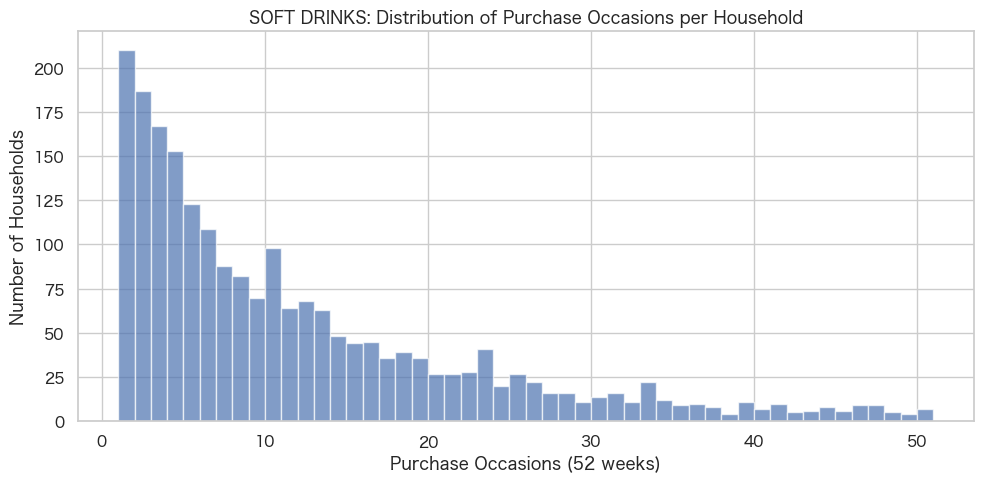

In [ ]:
# Distribution of category purchase occasions
fig, ax = plt.subplots(figsize=(10, 5))
max_occ = min(df_hh_occasion["purchase_occasions"].max(), 50)
ax.hist(
    df_hh_occasion["purchase_occasions"],
    bins=range(1, max_occ + 2),
    edgecolor="white",
    alpha=0.7,
)
ax.set_xlabel("Purchase Occasions (52 weeks)")
ax.set_ylabel("Number of Households")
ax.set_title("SOFT DRINKS: Distribution of Purchase Occasions per Household")
plt.tight_layout()
plt.show()

# ユーザーごとに成功確率が異なる試行の分布なので、負の二項分布に従うと考えて良い

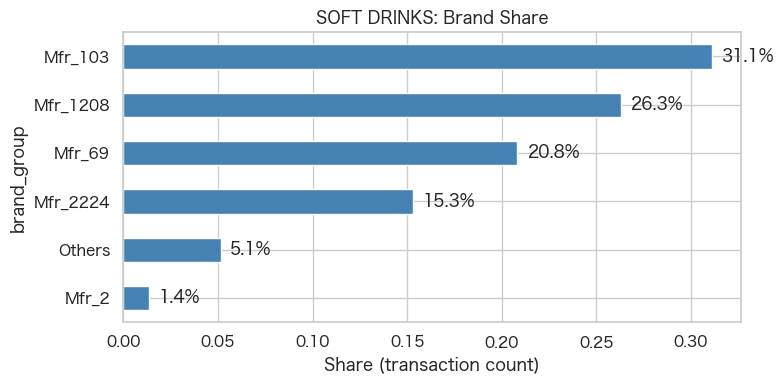

In [12]:
# Brand share
brand_share = df_sd["brand_group"].value_counts(normalize=True).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
brand_share.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Share (transaction count)")
ax.set_title("SOFT DRINKS: Brand Share")
for i, v in enumerate(brand_share.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.show()

## Step 2: 負の二項分布（NBD）モデル

### モデルの導出

消費者 $i$ のカテゴリ購入回数 $x_i$ をモデリングする。

**仮定1（個人レベル）**: 各消費者の購入はポアソン過程に従う。購入率 $\lambda_i$ を持つ消費者の $T$ 期間における購入回数は

$$
x_i \mid \lambda_i \sim \mathrm{Poisson}(\lambda_i T)
$$

**仮定2（集団レベル）**: 消費者間の購入率の異質性をガンマ分布で表現する。

$$
\lambda_i \sim \mathrm{Gamma}(K, \alpha)
$$

ここで $K$ は形状パラメータ（消費者の異質性を表す）、$\alpha$ はレートパラメータである。

**導出**: $\lambda$ を積分消去すると、

$$
P(X = x) = \int_0^{\infty} \frac{(\lambda T)^x e^{-\lambda T}}{x!} \cdot \frac{\alpha^K \lambda^{K-1} e^{-\alpha \lambda}}{\Gamma(K)} d\lambda = \binom{x + K - 1}{x} \left(\frac{\alpha}{\alpha + T}\right)^K \left(\frac{T}{\alpha + T}\right)^x
$$

ここで $M = K / \alpha$（プリファレンス：集団全体の平均購入回数）と置くと $\alpha = K/M$ となり、PMF は次の **M, K 表記**に書き換えられる。

$$
P(X = x) = \binom{x + K - 1}{x} \left(\frac{K}{K + M}\right)^K \left(\frac{M}{K + M}\right)^x
$$

### パラメータの意味

| パラメータ | 意味 |
|-----------|------|
| $M$ | **プリファレンス**（平均購入回数）。ブランドへの選好の強さを表す |
| $K$ | **形状パラメータ**（消費者異質性の逆指標）。小さいほど消費者間の購買率のばらつきが大きい。$K \to \infty$ でポアソン分布に収束（消費者が均一） |
| 平均 | $\mu = M$ |
| 分散 | $\sigma^2 = M + M^2/K$。$K$ が大きいほどポアソン（$\sigma^2 = M$）に近づき、小さいほど過分散が強まる |

### 2.1 MLE によるパラメータ推定

In [13]:
from scipy.stats import nbinom
from scipy.optimize import minimize

observed = df_hh_occasion["purchase_occasions"].values

def nbd_neg_loglik(params, data):
    r, p = params
    if r <= 0 or p <= 0 or p >= 1:
        return 1e10
    return -nbinom.logpmf(data, n=r, p=p).sum()

# Initial estimates from method of moments
mean_x = observed.mean()
var_x = observed.var()
p_init = mean_x / var_x
r_init = mean_x * p_init / (1 - p_init)

result = minimize(
    nbd_neg_loglik,
    x0=[r_init, p_init],
    args=(observed,),
    method="Nelder-Mead",
    options={"maxiter": 10000},
)

r_hat, p_hat = result.x
K_hat = r_hat
M_hat = r_hat * (1 - p_hat) / p_hat

print(f"K = {K_hat:.4f}  (形状パラメータ: 消費者異質性の逆指標)")
print(f"M = {M_hat:.4f}  (プリファレンス: 平均購入回数)")
print(f"Mean (model): {M_hat:.2f} | Mean (data): {mean_x:.2f}")
print(f"Var  (model): {M_hat + M_hat**2 / K_hat:.2f} | Var  (data): {var_x:.2f}")

K = 0.9905  (形状パラメータ: 消費者異質性の逆指標)
M = 15.1047  (プリファレンス: 平均購入回数)
Mean (model): 15.10 | Mean (data): 15.11
Var  (model): 245.44 | Var  (data): 406.20


### 2.2 実測値 vs フィッティング結果の比較

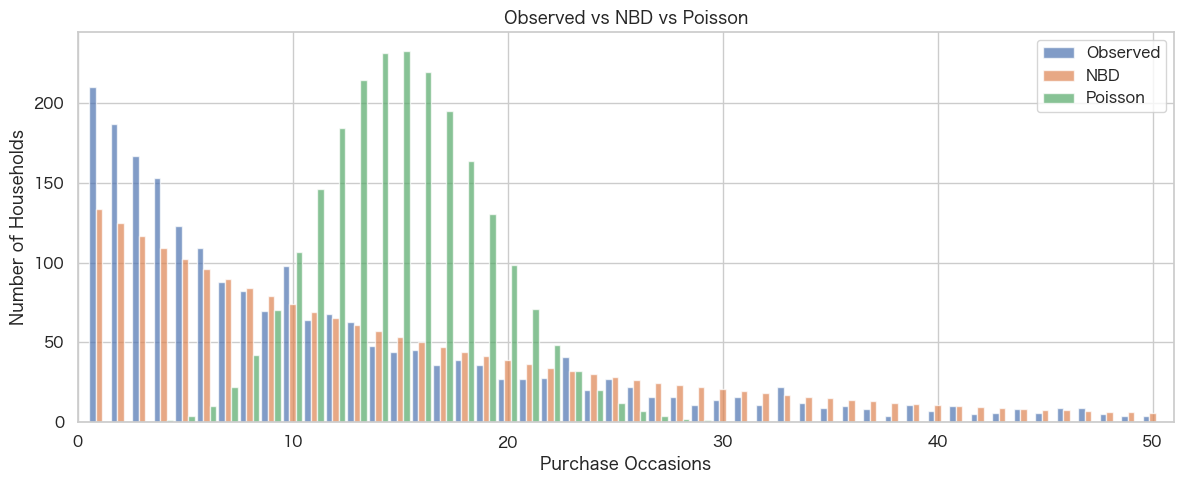

In [14]:
max_x = 50
x_vals = np.arange(1, max_x + 1)
n_hh = len(observed)

# Observed frequency
obs_freq = np.bincount(observed, minlength=max_x + 1)[1:max_x + 1]

# NBD expected frequency
nbd_expected = nbinom.pmf(x_vals, n=r_hat, p=p_hat) * n_hh

# Poisson expected frequency (for comparison)
from scipy.stats import poisson
poisson_expected = poisson.pmf(x_vals, mu=mean_x) * n_hh

fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.3
ax.bar(x_vals - bar_width, obs_freq, width=bar_width, label="Observed", alpha=0.7)
ax.bar(x_vals, nbd_expected, width=bar_width, label="NBD", alpha=0.7)
ax.bar(x_vals + bar_width, poisson_expected, width=bar_width, label="Poisson", alpha=0.7)
ax.set_xlabel("Purchase Occasions")
ax.set_ylabel("Number of Households")
ax.set_title("Observed vs NBD vs Poisson")
ax.legend()
ax.set_xlim(0, max_x + 1)
plt.tight_layout()
plt.show()

### 2.3 パラメータの解釈

In [15]:
overdispersion = var_x / mean_x
cv = 1 / np.sqrt(K_hat)  # coefficient of variation of lambda across households

print("=== NBD Model Interpretation (M, K parameterization) ===")
print(f"M = {M_hat:.2f}  (プリファレンス: 平均購入回数)")
print(f"K = {K_hat:.4f}  (形状パラメータ)")
print(f"CV of λ = 1/√K = {cv:.2f}  (購買率の変動係数: 消費者の異質性)")
print(f"\n過分散 (Var/Mean): {overdispersion:.2f}")
print(f"  -> ポアソンなら 1.0、実データは {overdispersion:.1f} 倍の過分散")

=== NBD Model Interpretation (M, K parameterization) ===
M = 15.10  (プリファレンス: 平均購入回数)
K = 0.9905  (形状パラメータ)
CV of λ = 1/√K = 1.00  (購買率の変動係数: 消費者の異質性)

過分散 (Var/Mean): 26.89
  -> ポアソンなら 1.0、実データは 26.9 倍の過分散


## Step 3: ブランド別 NBD フィッティング

カテゴリ全体ではなく、各ブランド（メーカー）ごとに NBD をフィッティングし、M, K パラメータを比較する。

M, K 表記での PMF：

$$
P(X = x) = \binom{x+K-1}{x} \left(\frac{K}{K+M}\right)^K \left(\frac{M}{K+M}\right)^x
$$

同じ平均購入回数 $M$ でも $K$ の違いからブランドの購買構造が異なることが読み取れる。

### 浸透率・購入頻度の計算ロジック

M, K パラメータから浸透率と購入頻度を算出する。

$$
\text{Penetration} = 1 - P(X = 0) = 1 - \left(\frac{K}{K+M}\right)^K
$$

$$
\text{Buying Rate} = \frac{M}{\text{Penetration}}
$$

「多くの人が少しずつ買うブランド」と「少数のヘビーバイヤーが繰り返し買うブランド」を区別できる。

### 3.1 ブランド別の購入回数データ作成

In [17]:
# All households in the panel (including those who bought 0 of a given brand)
all_households = df_hh_occasion["household_key"].unique()
n_total_hh = len(all_households)

brand_cols = sorted(df_hh_brand_wide.columns.tolist())

# For each brand: purchase occasions per household (including 0s)
brand_data = {}
for col in brand_cols:
    series = df_hh_brand_wide[col].reindex(all_households, fill_value=0).values
    brand_data[col] = series

print(f"Total households in panel: {n_total_hh}")
print(f"Brands: {brand_cols}")

Total households in panel: 2272
Brands: ['Mfr_103', 'Mfr_1208', 'Mfr_2', 'Mfr_2224', 'Mfr_69', 'Others']


### 3.2 各ブランドへの NBD フィッティング

In [18]:
def fit_nbd(data):
    """Fit NBD to purchase count data via MLE. Returns (K, M)."""
    mean_x = data.mean()
    var_x = data.var()
    if var_x <= mean_x:
        var_x = mean_x + 0.1
    p_init = mean_x / var_x
    r_init = mean_x * p_init / (1 - p_init)

    result = minimize(
        nbd_neg_loglik,
        x0=[r_init, p_init],
        args=(data,),
        method="Nelder-Mead",
        options={"maxiter": 10000},
    )
    r_est, p_est = result.x
    K_est = r_est
    M_est = r_est * (1 - p_est) / p_est
    return K_est, M_est

results = []
for col in brand_cols:
    data = brand_data[col]
    K_b, M_b = fit_nbd(data)
    p_b = K_b / (K_b + M_b)  # for nbinom.pmf calls
    penetration = 1 - nbinom.pmf(0, n=K_b, p=p_b)
    buying_rate = M_b / penetration if penetration > 0 else 0
    obs_penetration = (data > 0).mean()

    results.append({
        "Brand": col,
        "K": K_b,
        "M": M_b,
        "Penetration (model)": penetration,
        "Penetration (obs)": obs_penetration,
        "Buying Rate": buying_rate,
    })

df_nbd_results = pd.DataFrame(results)
df_nbd_results

,Brand,K,M,Penetration (model),Penetration (obs),Buying Rate
0,Mfr_103,0.489205,5.900601,0.715522,0.754842,8.246571
1,Mfr_1208,0.577420,5.007997,0.730278,0.766285,6.857655
2,Mfr_2,0.157127,0.264504,0.143667,0.144806,1.841087
3,Mfr_2224,0.542419,3.125452,0.645392,0.676937,4.842722
4,Mfr_69,0.212615,3.329856,0.450148,0.463908,7.397243
5,Others,0.301548,1.104847,0.371451,0.382482,2.974413


### 3.3 ブランド間パラメータ比較の可視化

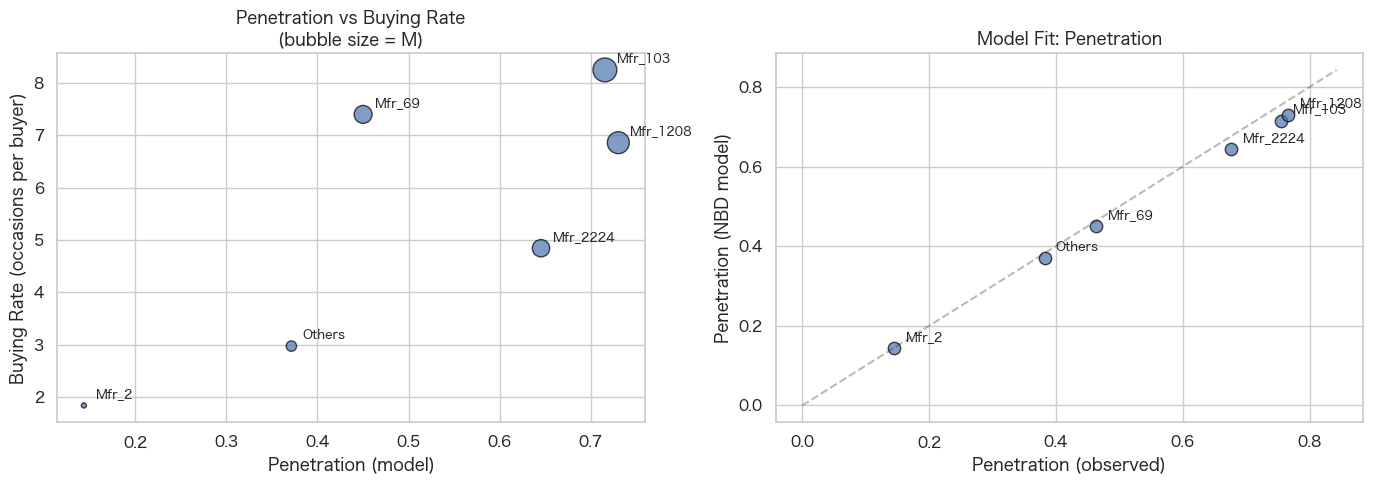

In [20]:
# Penetration vs Buying Rate scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Penetration vs Buying Rate
ax = axes[0]
ax.scatter(
    df_nbd_results["Penetration (model)"],
    df_nbd_results["Buying Rate"],
    s=df_nbd_results["M"] * 50,
    alpha=0.7,
    edgecolors="black",
)
for _, row in df_nbd_results.iterrows():
    ax.annotate(
        row["Brand"],
        (row["Penetration (model)"], row["Buying Rate"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )
ax.set_xlabel("Penetration (model)")
ax.set_ylabel("Buying Rate (occasions per buyer)")
ax.set_title("Penetration vs Buying Rate\n(bubble size = M)")

# Right: Observed vs Model penetration
ax = axes[1]
ax.scatter(
    df_nbd_results["Penetration (obs)"],
    df_nbd_results["Penetration (model)"],
    s=80,
    alpha=0.7,
    edgecolors="black",
)
lim = [0, max(df_nbd_results["Penetration (obs)"].max(), df_nbd_results["Penetration (model)"].max()) * 1.1]
ax.plot(lim, lim, "k--", alpha=0.3)
for _, row in df_nbd_results.iterrows():
    ax.annotate(
        row["Brand"],
        (row["Penetration (obs)"], row["Penetration (model)"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )
ax.set_xlabel("Penetration (observed)")
ax.set_ylabel("Penetration (NBD model)")
ax.set_title("Model Fit: Penetration")

plt.tight_layout()
plt.show()

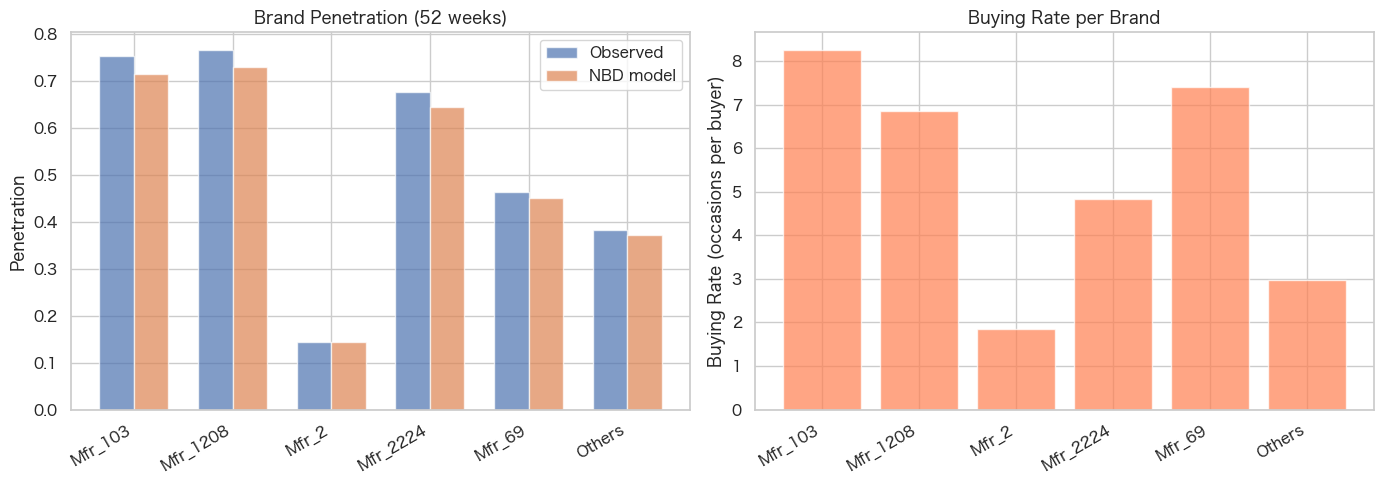

In [21]:
# Bar chart comparison: Penetration and Buying Rate side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(brand_cols))

ax = axes[0]
ax.bar(x_pos, df_nbd_results["Penetration (obs)"], width=0.35, label="Observed", alpha=0.7)
ax.bar(x_pos + 0.35, df_nbd_results["Penetration (model)"], width=0.35, label="NBD model", alpha=0.7)
ax.set_xticks(x_pos + 0.175)
ax.set_xticklabels(df_nbd_results["Brand"], rotation=30, ha="right")
ax.set_ylabel("Penetration")
ax.set_title("Brand Penetration (52 weeks)")
ax.legend()

ax = axes[1]
ax.bar(x_pos, df_nbd_results["Buying Rate"], color="coral", alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_nbd_results["Brand"], rotation=30, ha="right")
ax.set_ylabel("Buying Rate (occasions per buyer)")
ax.set_title("Buying Rate per Brand")

plt.tight_layout()
plt.show()

### 3.4 ブランド別フィッティングの可視化

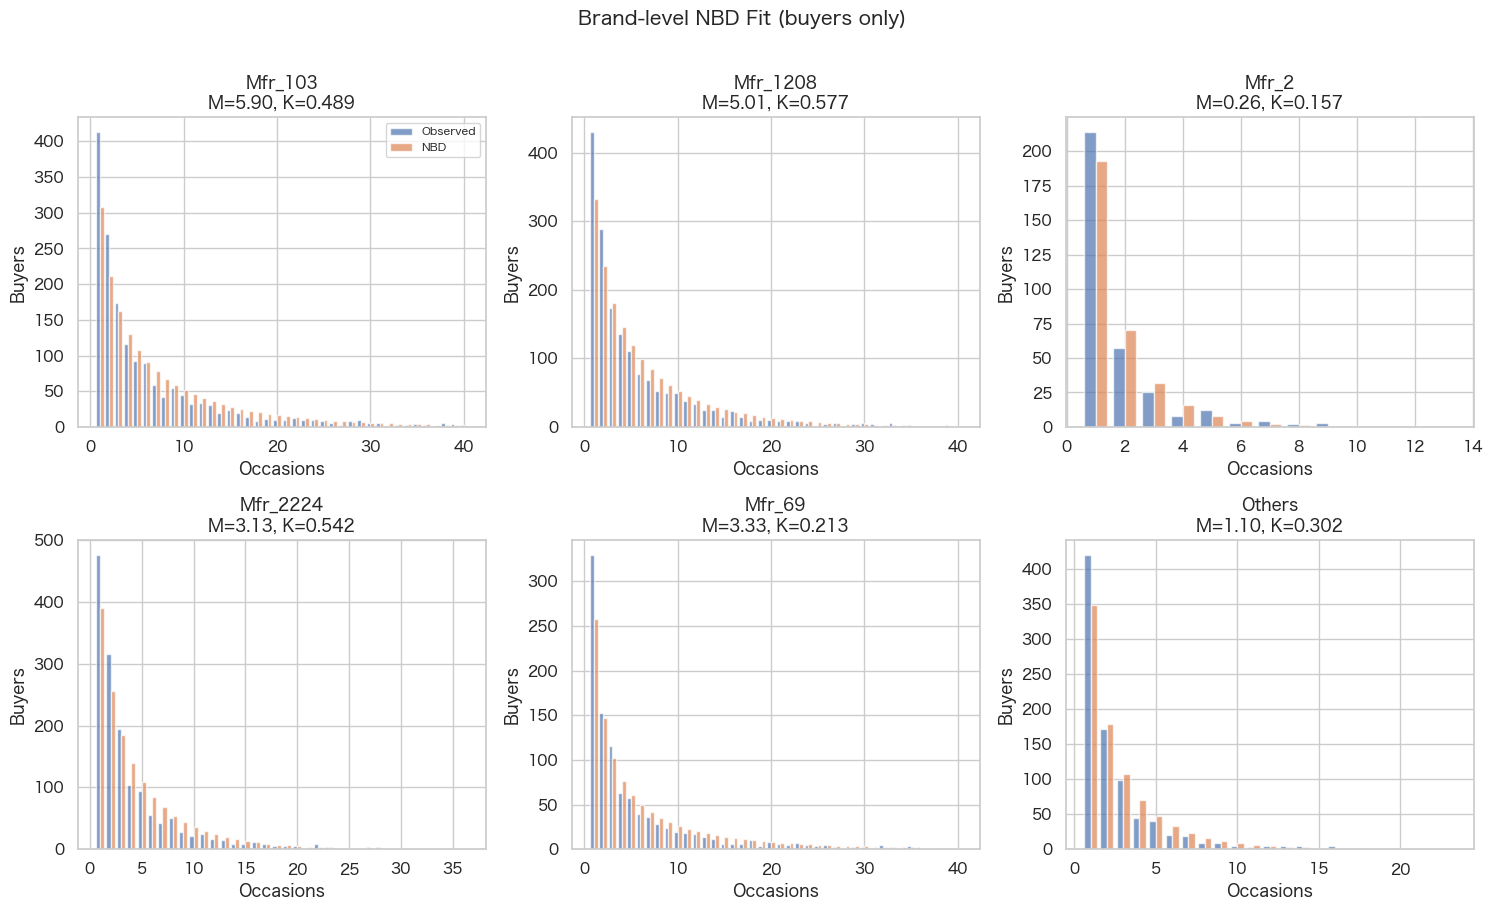

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (col, row_data) in enumerate(zip(brand_cols, results)):
    ax = axes[idx]
    data = brand_data[col]
    buyers = data[data > 0]
    max_x_b = min(int(np.percentile(buyers, 99)) + 5, 40) if len(buyers) > 0 else 10
    x_range = np.arange(1, max_x_b + 1)

    obs_freq_b = np.bincount(buyers, minlength=max_x_b + 1)[1:max_x_b + 1]

    K_b, M_b = row_data["K"], row_data["M"]
    p_b = K_b / (K_b + M_b)
    pmf_vals = nbinom.pmf(x_range, n=K_b, p=p_b)
    p0 = nbinom.pmf(0, n=K_b, p=p_b)
    nbd_cond = pmf_vals / (1 - p0) * len(buyers)

    ax.bar(x_range - 0.2, obs_freq_b, width=0.4, label="Observed", alpha=0.7)
    ax.bar(x_range + 0.2, nbd_cond, width=0.4, label="NBD", alpha=0.7)
    ax.set_title(f"{col}\nM={M_b:.2f}, K={K_b:.3f}")
    ax.set_xlabel("Occasions")
    ax.set_ylabel("Buyers")
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle("Brand-level NBD Fit (buyers only)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 考察

In [23]:
df_summary = df_nbd_results[["Brand", "K", "M", "Penetration (model)", "Penetration (obs)", "Buying Rate"]].copy()
df_summary = df_summary.sort_values("Penetration (model)", ascending=False)
df_summary = df_summary.rename(columns={
    "Penetration (model)": "Pen (model)",
    "Penetration (obs)": "Pen (obs)",
})
df_summary = df_summary.round(4)
df_summary

,Brand,K,M,Pen (model),Pen (obs),Buying Rate
1,Mfr_1208,0.5774,5.0080,0.7303,0.7663,6.8577
0,Mfr_103,0.4892,5.9006,0.7155,0.7548,8.2466
3,Mfr_2224,0.5424,3.1255,0.6454,0.6769,4.8427
4,Mfr_69,0.2126,3.3299,0.4501,0.4639,7.3972
5,Others,0.3015,1.1048,0.3715,0.3825,2.9744
2,Mfr_2,0.1571,0.2645,0.1437,0.1448,1.8411
